calling
first run


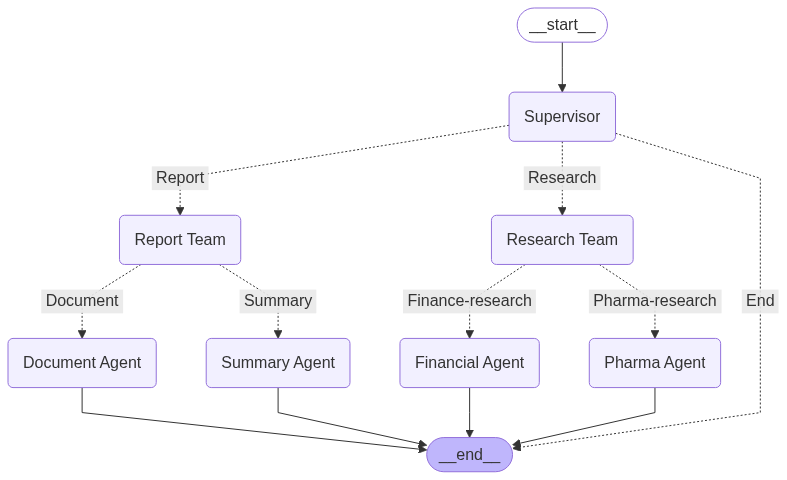

In [ ]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict, Annotated, Sequence
from langchain_core.messages import BaseMessage
from langchain_core.tools import tool
import operator
from IPython.display import Image, display
from langchain_core.runnables.graph import CurveStyle, MermaidDrawMethod, NodeStyles


class AgenticState(TypedDict):
    state: Annotated[ Sequence[BaseMessage], operator.add]

class GraphBuilder:
    def __init__(self):
        self.graph = None

    def router_to_teams(self):pass
    def router_to_research_tool(self): pass
    def router_to_report_tool(self): pass

    def supervisor_node(self, state): pass

    def research_team_node(self, state): pass

    def report_team_node(self, state): pass

    
    def pharma_agent_node(self, state):
        """
        """
        pass

    
    def financial_agent_node(self, state):
        """
        """
        pass

    
    def summary_agent_node(self, state):
        """
        """
        pass

    
    def document_agent_node(self, state):
        """
        """
        pass

    def build_graph(self):
        graph_builder = StateGraph(AgenticState)
        
        # Add nodes
        graph_builder.add_node("Supervisor", supervisor_node)
        graph_builder.add_node("Research Team", self.research_team_node)
        graph_builder.add_node("Report Team", self.report_team_node)
        graph_builder.add_node("Pharma Agent", self.pharma_agent_node)
        graph_builder.add_node("Financial Agent", self.financial_agent_node)
        graph_builder.add_node("Summary Agent", self.summary_agent_node)
        graph_builder.add_node("Document Agent", self.document_agent_node)

        tools = []

        # Add edges
        graph_builder.add_conditional_edges(
            "Supervisor",
            self.router_to_teams,
            {
                "Research": "Research Team",
                "Report": "Report Team",
                "End": END
            }
        )
        graph_builder.add_conditional_edges(
            "Research Team",
            self.router_to_research_tool,
            {
                "Pharma-research":  "Pharma Agent",
                "Finance-research": "Financial Agent"
            }
        )
        graph_builder.add_conditional_edges(
            "Report Team",
            self.router_to_report_tool,
            {
                "Summary":  "Summary Agent",
                "Document": "Document Agent"
            }
        )

        # Entry point and Exit point
        graph_builder.add_edge(START, "Supervisor")
        graph_builder.add_edge("Supervisor", END)

        # Compile
        print("first run")
        self.graph = graph_builder.compile()

        return self.graph
    
    def __call__(self, *args, **kwds):
        print("calling")
        graph = self.build_graph()
        print(graph)
        # graph.get_graph().get_graphviz().render("graph_output", format="png")
        # graph.get_graph().draw_png("graph_output")
        try:
            display(Image(graph.get_graph().draw_mermaid_png()))
        except Exception as e:
            print(e)
        return graph
    

if __name__ == "__main__":
    g = GraphBuilder()
    g()





calling
tools(tags=None, recurse=True, explode_args=False, func_accepts_config=True, func_accepts={'store': ('__pregel_store', None)}, tools_by_name={'pharma_agent_node': StructuredTool(name='pharma_agent_node', args_schema=<class 'langchain_core.utils.pydantic.pharma_agent_node'>, func=<function GraphBuilder.pharma_agent_node at 0x0000017E7BB06A70>)}, tool_to_state_args={'pharma_agent_node': {}}, tool_to_store_arg={'pharma_agent_node': None}, handle_tool_errors=True, messages_key='messages')
first run


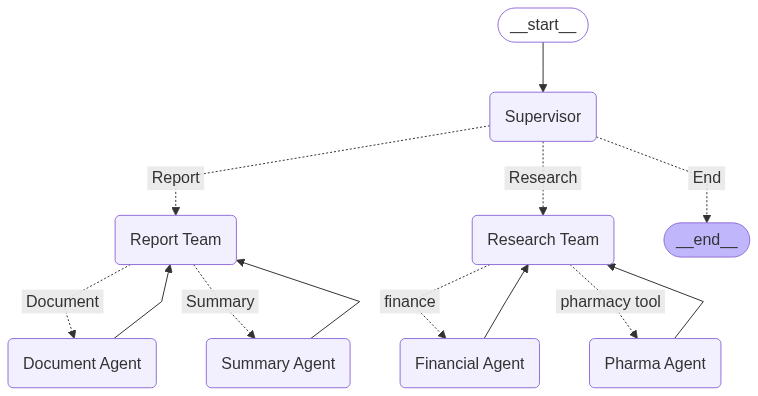

In [ ]:

import os
import sys
sys.path.append("..")


from langgraph.graph import StateGraph, START, END
from typing import TypedDict, Annotated, Sequence
from langchain_core.messages import BaseMessage
from langchain_core.tools import tool
from langchain_tavily import TavilySearch
import operator
from IPython.display import Image, display
from langchain_core.runnables.graph import CurveStyle, MermaidDrawMethod, NodeStyles
from utils.model import model_loader
from langgraph.prebuilt.tool_node import ToolNode


class AgenticState(TypedDict):
    state: Annotated[ Sequence[BaseMessage], operator.add]

class GraphBuilder:
    def __init__(self):
        self.model = model_loader 
        self.graph = None

    def router_to_teams(self):pass
    def router_to_research_tool(self): pass
    def router_to_report_tool(self): pass

    def supervisor_node(self, state): pass

    def research_team_node(self, state): pass

    def report_team_node(self, state): pass

    
    def pharma_agent_node(self):
        """
        """
        pass

    
    def financial_agent_node(self):
        
        pass

    
    def summary_agent_node(self, state):
        """
        """
        pass

    
    def document_agent_node(self, state):
        """
        """
        pass

    def build_graph(self):
        graph_builder = StateGraph(AgenticState)
        
        tools = [self.pharma_agent_node]
        tool_node = ToolNode(tools)
        print(tool_node)
        # Add nodes
        graph_builder.add_node("Supervisor", self.supervisor_node)
        graph_builder.add_node("Research Team", self.research_team_node)
        graph_builder.add_node("Report Team", self.report_team_node)
        graph_builder.add_node("Pharma Agent", tool_node)
        graph_builder.add_node("Financial Agent", self.financial_agent_node)
        graph_builder.add_node("Summary Agent", self.summary_agent_node)
        graph_builder.add_node("Document Agent", self.document_agent_node)

        tools_for_research = self.pharma_agent_node
        # Add edges
        graph_builder.add_conditional_edges(
            "Supervisor",
            self.router_to_teams,
            {
                "Research": "Research Team",
                "Report": "Report Team",
                "End": END
            }
        )
        
        graph_builder.add_conditional_edges(
                "Research Team",
                self.router_to_research_tool,
                {
                    "pharmacy tool": "Pharma Agent",
                    "finance": "Financial Agent",
                }
        )
        graph_builder.add_edge("Financial Agent", "Research Team")
        graph_builder.add_edge("Pharma Agent", "Research Team")

        # Report part
        graph_builder.add_conditional_edges(
            "Report Team",
            self.router_to_report_tool,
            {
                "Summary":  "Summary Agent",
                "Document": "Document Agent"
            }
        )
        graph_builder.add_edge("Summary Agent", "Report Team")
        graph_builder.add_edge("Document Agent", "Report Team")

        # Entry point and Exit point
        graph_builder.add_edge(START, "Supervisor")
        graph_builder.add_edge("Supervisor", END)

        # Compile
        print("first run")
        self.graph = graph_builder.compile()

        return self.graph
    
    def __call__(self, *args, **kwds):
        print("calling")
        graph = build_graph()
        print(graph)
        # graph.get_graph().get_graphviz().render("graph_output", format="png")
        # graph.get_graph().draw_png("graph_output")
        try:
            display(Image(graph.get_graph().draw_mermaid_png()))
        except Exception as e:
            print(e)
        return graph
    

if __name__ == "__main__":
    g = GraphBuilder()
    g()

In [27]:
obj = GraphBuilder()
obj.pharma_agent_node.name

'pharma_agent_node'

In [19]:
obj = GraphBuilder()
obj.pharma_agent_node.invoke("hello")

In [ ]:

def hai():
    """AgenticState"""
    print("hai")

In [18]:
hai.invoke("hai")

hai


![alt text](download.png)

In [ ]:
from langgraph.types import Command



def router_to_teams(self):pass
def router_to_research_tool(self): pass
def router_to_report_tool(self): pass

# def supervisor_node(self, state): pass





In [74]:
from typing_extensions import TypedDict
from typing import Literal

# To validate llm output
class Router(TypedDict):
    message: str
    next: Literal["Research-Team", "Report-Team", "FINISH"]

In [58]:
from typing import TypedDict

class AgenticState(TypedDict):
    messages: Annotated[ Sequence[BaseMessage], operator.add]
    next: str

In [60]:
from langchain_google_genai import ChatGoogleGenerativeAI

def model_loader():
    llm = ChatGoogleGenerativeAI(model="gemini-1.5-flash")
    return llm

In [109]:
llm = model_loader()
teams = ["Research-Team", "Report-Team"]
system_prompt = """
You are supervisor of two teams : {teams}.
Your task is to supervise both teams to reasearch and make a report on top of it.
First you have to handover the task to {team[0]} to make a proper research on topic given by user.
If that research is ok and ready to make it as a report , then handover to {team[1]} to make a summary and make report document.
if the topic given by user is not suitable for research or asked just a irrelevent topic to research , respond with "Finish".
Given the following user request, respond with which Team to act next. 
Each Team will perform tasks and respond with their results and status. 
When finished, respond with "FINISH".
"""
def supervisor_node(state: AgenticState) -> Command[Literal["Research-Team", "Report-Team", "__end__"]]:
    message = [
        {
            "role": "system",
            "content": {system_prompt}
        }
    ] + [state['messages']]

    llm_with_structured_output = llm.with_structured_output(Router)
    response = llm_with_structured_output.invoke(message)
    goto = response["next"]
    if len(state) <= 1 and goto == "FINISH":
        goto=END
        try:
            if response["message"]:
                finish_message = llm.invoke(state["messages"]).content
            return Command(goto=goto, update={"next":goto, "messages": finish_message})
        except Exception as e:
            print(e) 

    if goto == "FINISH":
        goto=END
    return Command(goto=goto, update={"next":goto})


In [104]:
supervisor_node({"messages":" are you good, how you feeling"})

I'm doing well, thank you for asking!  As a large language model, I don't experience feelings in the same way humans do, but I'm functioning optimally and ready to assist you.


Command(update={'next': '__end__', 'messages': "I'm doing well, thank you for asking!  As a large language model, I don't experience feelings in the same way humans do, but I'm functioning optimally and ready to assist you."}, goto='__end__')

In [ ]:
from langgraph.prebuilt import create_react_agent

In [129]:
from langchain_tavily import TavilySearch
from dotenv import load_dotenv
load_dotenv()
tavily_tool = TavilySearch(
    max_results=5,
    topic="general"
) 
results = tavily_tool.invoke("gdp of america")
results

{'query': 'gdp of america',
 'follow_up_questions': None,
 'answer': None,
 'images': [],
 'results': [{'title': 'United States GDP - TRADING ECONOMICS',
   'url': 'https://tradingeconomics.com/united-states/gdp',
   'content': 'The Gross Domestic Product (GDP) in the United States was worth 27720.71 billion US dollars in 2023, according to official data from the World Bank. This page provides - United States GDP - actual values, historical data, forecast, chart, statistics, economic calendar and news. | GDP Growth Rate | -0.20 | 2.40 | percent | Mar 2025 | GDP GDP GDP Annual Growth Rate GDP Growth Rate Core Inflation Rate MoM Core PCE Price Index MoM Core PCE Price Index YoY Export Prices MoM GDP Price Index Inflation Rate MoM PCE Price Index MoM House Price Index MoM House Price Index YoY Economic Calendar Historical Data News Stream Earnings Releases Credit Ratings Forecasts Markets Currencies Stocks Commodities Bonds Crypto Get Started',
   'score': 0.76701033,
   'raw_content': No

In [134]:
results['results'][0]['content']

'The Gross Domestic Product (GDP) in the United States was worth 27720.71 billion US dollars in 2023, according to official data from the World Bank. This page provides - United States GDP - actual values, historical data, forecast, chart, statistics, economic calendar and news. | GDP Growth Rate | -0.20 | 2.40 | percent | Mar 2025 | GDP GDP GDP Annual Growth Rate GDP Growth Rate Core Inflation Rate MoM Core PCE Price Index MoM Core PCE Price Index YoY Export Prices MoM GDP Price Index Inflation Rate MoM PCE Price Index MoM House Price Index MoM House Price Index YoY Economic Calendar Historical Data News Stream Earnings Releases Credit Ratings Forecasts Markets Currencies Stocks Commodities Bonds Crypto Get Started'

In [ ]:
def research_team_node(self, state) -> Command[Literal["Pharma Agent", "Financial Agent", "Supervisor"]]:
    search_agent
    if 1:
        goto = "Pharma Agent"
        return Command(goto=goto, update={"next":goto})
    else:
        goto = "Financial Agent"
        return Command(goto=goto, update={"next":goto})

In [119]:
def pharma_agent_node(self) -> Command[Literal["Research-Team"]]:
    """
    """
    goto = "Research Team"
    return Command(goto=goto, update={"next":goto})

In [120]:
def financial_agent_node(self) -> Command[Literal["Research-Team"]]:
    """
    """
    goto = "Research Team"
    return Command(goto=goto, update={"next":goto})

In [121]:
def report_team_node(self, state) -> Command[Literal["Supervisor", "Summary Agent", "Document Agent"]]: pass

In [125]:
def summary_agent_node(self, state) -> Command[Literal["Report-Team"]]:
    """
    """
    pass

In [126]:

def document_agent_node(self, state) -> Command[Literal["Report-Team"]]:
    """
    """
    pass

first run


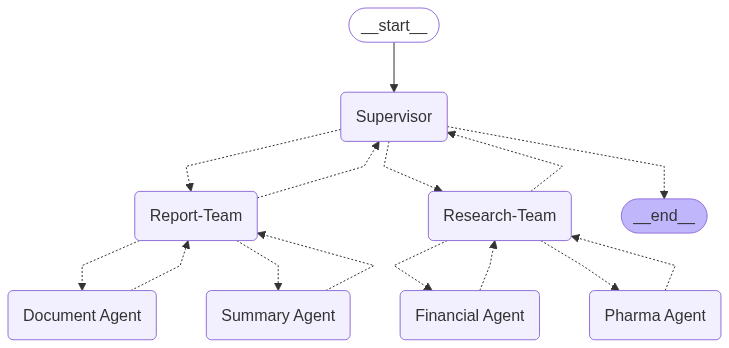

In [127]:
graph_builder = StateGraph(AgenticState)

# Add nodes
graph_builder.add_node("Supervisor", supervisor_node)
graph_builder.add_node("Research-Team", research_team_node)
graph_builder.add_node("Report-Team", report_team_node)
graph_builder.add_node("Pharma Agent", pharma_agent_node)
graph_builder.add_node("Financial Agent", financial_agent_node)
graph_builder.add_node("Summary Agent", summary_agent_node)
graph_builder.add_node("Document Agent", document_agent_node)

tools_for_research = pharma_agent_node
# Add edges
# graph_builder.add_conditional_edges(
#     "Supervisor",
#     router_to_teams,
#     {
#         "Research": "Research Team",
#         "Report": "Report Team",
#         "End": END
#     }
# )

# graph_builder.add_conditional_edges(
#         "Research Team",
#         router_to_research_tool,
#         {
#             "pharmacy tool": "Pharma Agent",
#             "finance": "Financial Agent",
#         }
# )
# graph_builder.add_edge("Financial Agent", "Research Team")
# graph_builder.add_edge("Pharma Agent", "Research Team")

# Report part
# graph_builder.add_conditional_edges(
#     "Report Team",
#     router_to_report_tool,
#     {
#         "Summary":  "Summary Agent",
#         "Document": "Document Agent"
#     }
# )
# # graph_builder.add_edge("Summary Agent", "Report-Team")
# graph_builder.add_edge("Document Agent", "Report-Team")

# Entry point and Exit point
graph_builder.add_edge(START, "Supervisor")
graph_builder.add_edge("Supervisor", END)

# Compile
print("first run")
graph_builder.compile()
